In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [2]:
flights = pd.read_csv('nyc_flights2.csv')

In [3]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,B6,2023,N324JB,JFK,SJU,535,...,1039.0,19.0,0,0,NaN,0.0,0.0,19.0,0.0,0.0
1,2015,1,1,4,AA,2299,N3LLAA,JFK,MIA,545,...,959.0,69.0,0,0,NaN,14.0,0.0,55.0,0.0,0.0
2,2015,1,1,4,B6,939,N794JB,JFK,BQN,545,...,1007.0,-19.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,B6,353,N570JB,JFK,PBI,600,...,836.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,B6,583,N531JB,JFK,MCO,600,...,832.0,-19.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
flights.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

array([[<Axes: title={'center': 'ARRIVAL_DELAY'}>]], dtype=object)

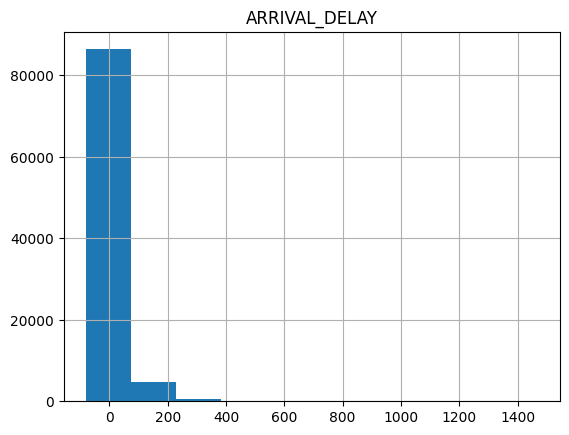

In [5]:
flights.hist(column=['ARRIVAL_DELAY'],)

In [6]:
flights['DELAYED'] = flights['ARRIVAL_DELAY'].apply(lambda x: 1 if x > 30 else 0)
flights['WEATHER_DELAY_BIN'] = flights['WEATHER_DELAY'].apply(lambda x: 1 if x > 30 else 0)
flights['LATE_AIRCRAFT_DELAY_BIN'] = flights['LATE_AIRCRAFT_DELAY'].apply(lambda x: 1 if x > 30 else 0)

array([[<Axes: title={'center': 'WEATHER_DELAY'}>]], dtype=object)

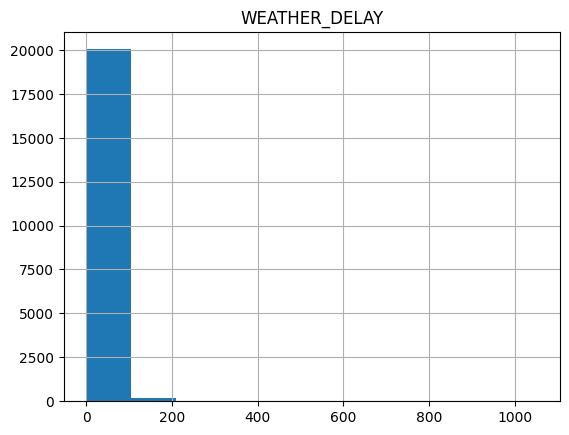

In [7]:
flights.hist(column=['WEATHER_DELAY'],)

array([[<Axes: title={'center': 'LATE_AIRCRAFT_DELAY_BIN'}>]],
      dtype=object)

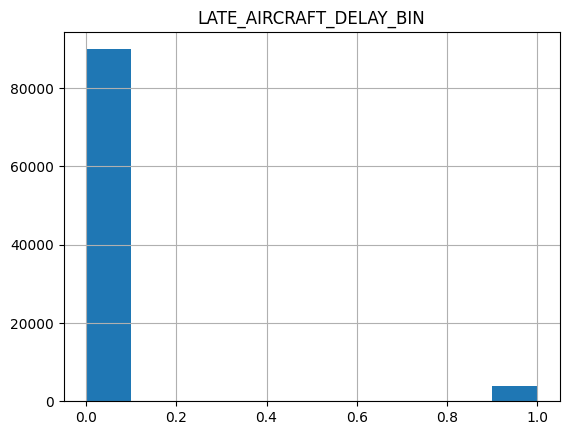

In [8]:
flights.hist(column=['LATE_AIRCRAFT_DELAY_BIN'],)

In [9]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAYED,WEATHER_DELAY_BIN,LATE_AIRCRAFT_DELAY_BIN
count,93811.0,93811.000000,93811.000000,93811.000000,93811.000000,93811.000000,91933.000000,91933.000000,91892.000000,91892.000000,...,93811.000000,93811.000000,20260.000000,20260.000000,20260.000000,20260.000000,20260.000000,93811.000000,93811.000000,93811.000000
mean,2015.0,6.149513,15.719756,3.966539,958.411999,1364.161633,1355.709810,12.128115,27.009783,1382.360260,...,0.002409,0.020488,16.562488,0.290326,22.204294,19.731935,4.588500,0.137073,0.008954,0.042308
std,0.0,3.368418,8.788328,2.004153,922.922097,495.722481,518.477003,41.984448,13.649207,529.508708,...,0.049024,0.141663,26.296736,4.454243,48.639017,44.562383,26.590377,0.343927,0.094202,0.201293
min,2015.0,1.000000,1.000000,1.000000,1.000000,506.000000,1.000000,-22.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,3.000000,8.000000,2.000000,308.000000,900.000000,854.000000,-4.000000,18.000000,916.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,6.000000,16.000000,4.000000,501.000000,1429.000000,1419.000000,-1.000000,24.000000,1426.000000,...,0.000000,0.000000,8.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2015.0,9.000000,23.000000,6.000000,1407.000000,1800.000000,1809.000000,9.000000,32.000000,1825.000000,...,0.000000,0.000000,23.000000,0.000000,24.000000,20.000000,0.000000,0.000000,0.000000,0.000000
max,2015.0,12.000000,31.000000,7.000000,3684.000000,2359.000000,2400.000000,1429.000000,180.000000,2400.000000,...,1.000000,1.000000,437.000000,221.000000,1467.000000,939.000000,1052.000000,1.000000,1.000000,1.000000


In [10]:
feats = flights[['MONTH','DAY','DAY_OF_WEEK', 'AIRLINE', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
                'DISTANCE', 'LATE_AIRCRAFT_DELAY_BIN', 'WEATHER_DELAY_BIN', 'DELAYED']]

In [11]:
print('Proportion of delayed flights: ', feats.DELAYED.mean())

Proportion of delayed flights:  0.13707347752395774


In [12]:
feats.fillna(0)

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,LATE_AIRCRAFT_DELAY_BIN,WEATHER_DELAY_BIN,DELAYED
0,1,1,4,B6,SJU,535,1598,0,0,0
1,1,1,4,AA,MIA,545,1089,0,0,1
2,1,1,4,B6,BQN,545,1576,0,0,0
3,1,1,4,B6,PBI,600,1028,0,0,0
4,1,1,4,B6,MCO,600,944,0,0,0
...,...,...,...,...,...,...,...,...,...,...
93806,12,31,4,B6,BUF,2250,301,0,0,0
93807,12,31,4,B6,BOS,2312,187,0,0,0
93808,12,31,4,B6,PSE,2359,1617,0,0,0
93809,12,31,4,B6,SJU,2359,1598,0,0,0


In [13]:
feats['SCHEDULED_DEPARTURE'].apply(lambda x: round(x/100,0))


,SCHEDULED_DEPARTURE
0,5.0
1,5.0
2,5.0
3,6.0
4,6.0
...,...
93806,22.0
93807,23.0
93808,24.0
93809,24.0


In [14]:
feats.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DISTANCE', 'LATE_AIRCRAFT_DELAY_BIN',
       'WEATHER_DELAY_BIN', 'DELAYED'],
      dtype='object')

In [15]:
feats.describe()

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE,LATE_AIRCRAFT_DELAY_BIN,WEATHER_DELAY_BIN,DELAYED
count,93811.000000,93811.000000,93811.000000,93811.000000,93811.000000,93811.000000,93811.000000,93811.000000
mean,6.149513,15.719756,3.966539,1364.161633,1441.861146,0.042308,0.008954,0.137073
std,3.368418,8.788328,2.004153,495.722481,882.307644,0.201293,0.094202,0.343927
min,1.000000,1.000000,1.000000,506.000000,173.000000,0.000000,0.000000,0.000000
25%,3.000000,8.000000,2.000000,900.000000,740.000000,0.000000,0.000000,0.000000
50%,6.000000,16.000000,4.000000,1429.000000,1089.000000,0.000000,0.000000,0.000000
75%,9.000000,23.000000,6.000000,1800.000000,2446.000000,0.000000,0.000000,0.000000
max,12.000000,31.000000,7.000000,2359.000000,4983.000000,1.000000,1.000000,1.000000


In [16]:
X = pd.get_dummies(feats.drop('DELAYED', axis=1))
y = feats['DELAYED'].astype('category')

In [17]:
X.loc[:, X.isnull().any()].columns

Index([], dtype='object')

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)


In [19]:
delays_nb = MultinomialNB(alpha=0.01)
delays_nb.fit(X_train, y_train)

y_pred = delays_nb.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[14809 11945]
 [ 1862  2342]]
              precision    recall  f1-score   support

           0       0.89      0.55      0.68     26754
           1       0.16      0.56      0.25      4204

    accuracy                           0.55     30958
   macro avg       0.53      0.56      0.47     30958
weighted avg       0.79      0.55      0.62     30958



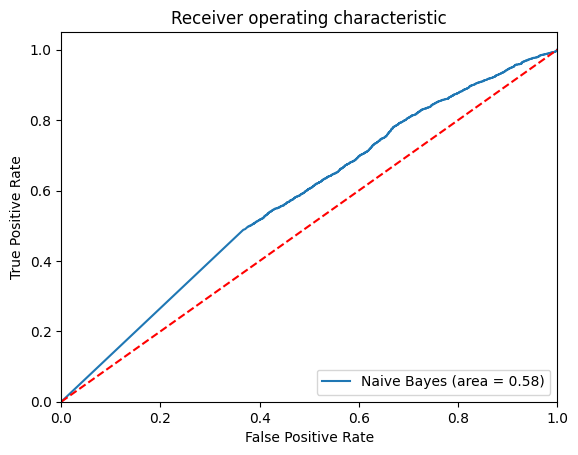

In [20]:
nb_roc_auc = roc_auc_score(y_test, delays_nb.predict_proba(X_test)[:,1])
nb_fpr, nb_tpr, nb_thresholds = roc_curve(y_test, delays_nb.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(nb_fpr, nb_tpr, label='Naive Bayes (area = %0.2f)' % nb_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [26]:
from sklearn.inspection import permutation_importance

r = permutation_importance(delays_nb, X_test, y_test,
                           n_repeats=5,
                           random_state=0)

for i in r.importances_mean.argsort()[::-1]:
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        print(f"{X_test.columns[i]:<8}"
              f"{r.importances_mean[i]:.3f}"
              f" +/- {r.importances_std[i]:.3f}")

SCHEDULED_DEPARTURE0.021 +/- 0.001
DISTANCE0.015 +/- 0.001
LATE_AIRCRAFT_DELAY_BIN0.002 +/- 0.000
WEATHER_DELAY_BIN0.000 +/- 0.000
DESTINATION_AIRPORT_DFW0.000 +/- 0.000
DESTINATION_AIRPORT_SAV0.000 +/- 0.000
AIRLINE_AA0.000 +/- 0.000
AIRLINE_B60.000 +/- 0.000
AIRLINE_DL0.000 +/- 0.000


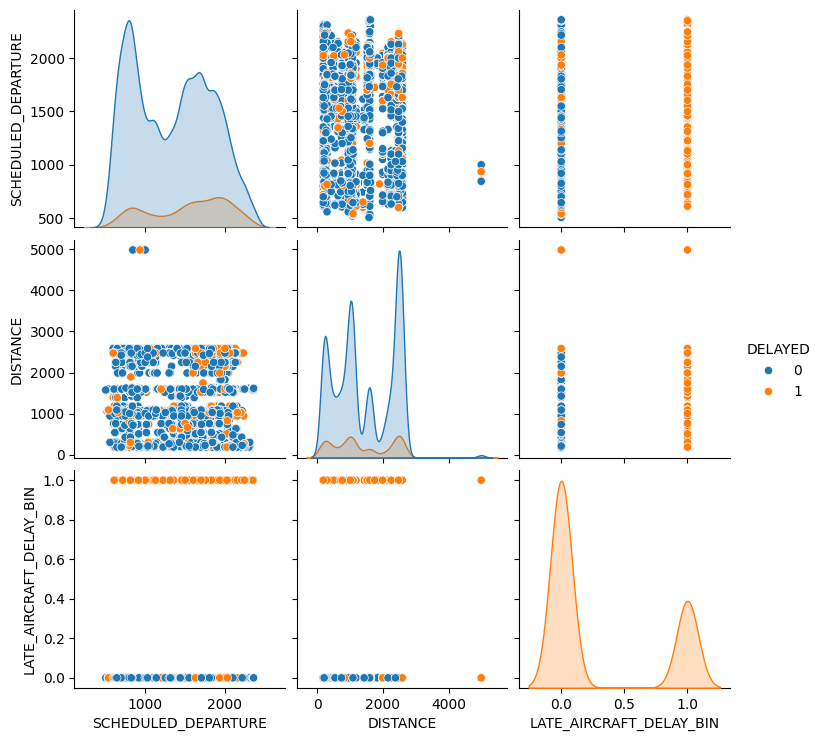

In [27]:
x_y = pd.concat([X_test,y_test], axis=1)

sns.pairplot(x_y[['SCHEDULED_DEPARTURE','DISTANCE','LATE_AIRCRAFT_DELAY_BIN','DELAYED']], hue='DELAYED')
